# Analisis Diabetes - Pima Indians
**Sumber:** [Kaggle - mathchi/diabetes-data-set](https://www.kaggle.com/datasets/mathchi/diabetes-data-set)

Dataset -> National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK). 
Populasi -> wanita keturunan Pima Indian berusia minimal 21 tahun. 
Dataset -> 768 pasien 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold',
})

df = pd.read_csv('diabetes_kaggle.csv')

print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
print(f"Nama kolom     : {df.columns.tolist()}")
df.head()


Jumlah baris   : 768
Jumlah kolom   : 9
Nama kolom     : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4,84,51,10,17,29.4,0.336,29,0
1,6,145,120,28,90,27.5,0.720,21,0
2,5,103,79,41,201,40.1,0.542,24,0
3,4,105,113,22,14,32.8,0.386,46,0
4,3,113,100,18,196,52.1,0.301,40,1


In [2]:
kolom_tidak_valid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Jumlah nilai 0 per kolom (sebelum cleansing):")
print((df[kolom_tidak_valid] == 0).sum())


df_clean = df.copy()
df_clean[kolom_tidak_valid] = df_clean[kolom_tidak_valid].replace(0, np.nan)

for col in kolom_tidak_valid:
    df_clean[col] = df_clean.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )

print("\nJumlah nilai kosong setelah cleansing:")
print(df_clean.isnull().sum())
print(f"\nDataset siap digunakan: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")


Jumlah nilai 0 per kolom (sebelum cleansing):
Glucose            0
BloodPressure      0
SkinThickness     81
Insulin          195
BMI                0
dtype: int64

Jumlah nilai kosong setelah cleansing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset siap digunakan: 768 baris, 9 kolom


In [3]:
df_clean['Diagnosis'] = df_clean['Outcome'].map({0: 'Tidak Diabetes', 1: 'Diabetes'})

def kategori_bmi(bmi):
    if bmi < 18.5: return 'Kurus'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Gemuk'
    else:          return 'Obesitas'

def kelompok_usia(age):
    if age < 30:   return '21-29'
    elif age < 40: return '30-39'
    elif age < 50: return '40-49'
    elif age < 60: return '50-59'
    else:          return '60+'

def kategori_glukosa(g):
    if g < 100:   return 'Normal'
    elif g < 126: return 'Pradiabetes'
    else:         return 'Diabetes'

df_clean['Kategori_BMI']     = df_clean['BMI'].apply(kategori_bmi)
df_clean['Kelompok_Usia']    = df_clean['Age'].apply(kelompok_usia)
df_clean['Kategori_Glukosa'] = df_clean['Glucose'].apply(kategori_glukosa)

df_clean[['Diagnosis','Kategori_BMI','Kelompok_Usia','Kategori_Glukosa']].head()


,Diagnosis,Kategori_BMI,Kelompok_Usia,Kategori_Glukosa
0,Tidak Diabetes,Gemuk,21-29,Normal
1,Tidak Diabetes,Gemuk,21-29,Diabetes
2,Tidak Diabetes,Obesitas,21-29,Pradiabetes
3,Tidak Diabetes,Obesitas,40-49,Pradiabetes
4,Diabetes,Obesitas,40-49,Pradiabetes


### Grafik 1 - Distribusi Pasien Diabetes dan Tidak Diabetes

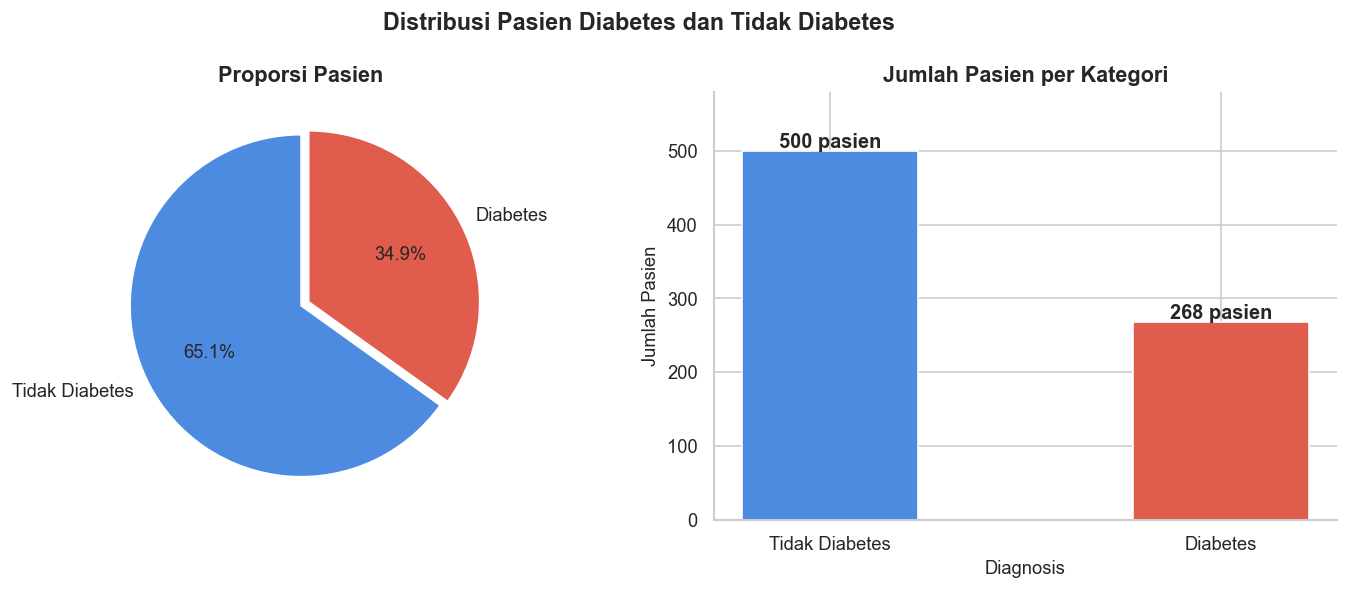

In [4]:
jumlah = df_clean['Diagnosis'].value_counts()
warna  = ['#4C8BE0', '#E05C4C']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie
axes[0].pie(
    jumlah.values,
    labels=jumlah.index,
    autopct='%1.1f%%',
    colors=warna,
    startangle=90,
    explode=(0, 0.05),
    textprops={'fontsize': 11}
)
axes[0].set_title('Proporsi Pasien')

# Bar
bar = axes[1].bar(jumlah.index, jumlah.values, color=warna, width=0.45, edgecolor='white')
for b, v in zip(bar, jumlah.values):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                 str(v) + ' pasien', ha='center', fontweight='bold')
axes[1].set_title('Jumlah Pasien per Kategori')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('Jumlah Pasien')
axes[1].set_ylim(0, 580)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Distribusi Pasien Diabetes dan Tidak Diabetes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Grafik 2 - Distribusi Kadar Glukosa Berdasarkan Diagnosis

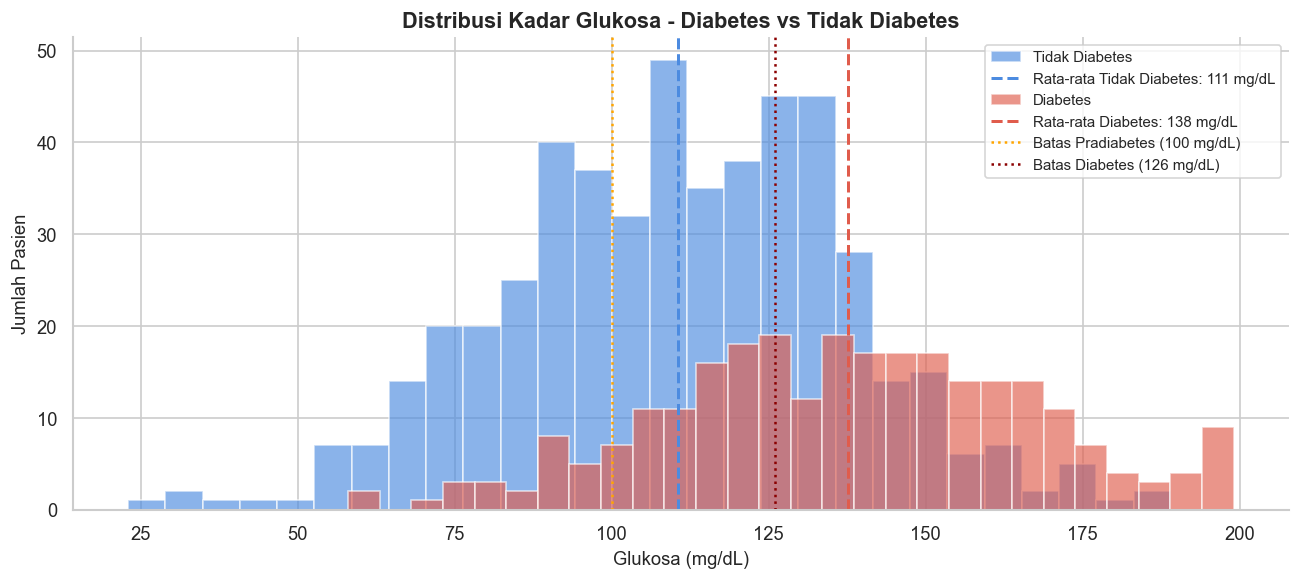

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

for label, warna in [('Tidak Diabetes', '#4C8BE0'), ('Diabetes', '#E05C4C')]:
    data = df_clean[df_clean['Diagnosis'] == label]['Glucose']
    ax.hist(data, bins=28, alpha=0.65, color=warna, label=label, edgecolor='white')
    ax.axvline(data.mean(), color=warna, linestyle='--', linewidth=1.8,
               label=f'Rata-rata {label}: {data.mean():.0f} mg/dL')

ax.axvline(100, color='orange', linestyle=':', linewidth=1.5, label='Batas Pradiabetes (100 mg/dL)')
ax.axvline(126, color='darkred', linestyle=':', linewidth=1.5, label='Batas Diabetes (126 mg/dL)')

ax.set_title('Distribusi Kadar Glukosa - Diabetes vs Tidak Diabetes')
ax.set_xlabel('Glukosa (mg/dL)')
ax.set_ylabel('Jumlah Pasien')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


### Grafik 3 - Perbandingan Fitur Klinis Utama

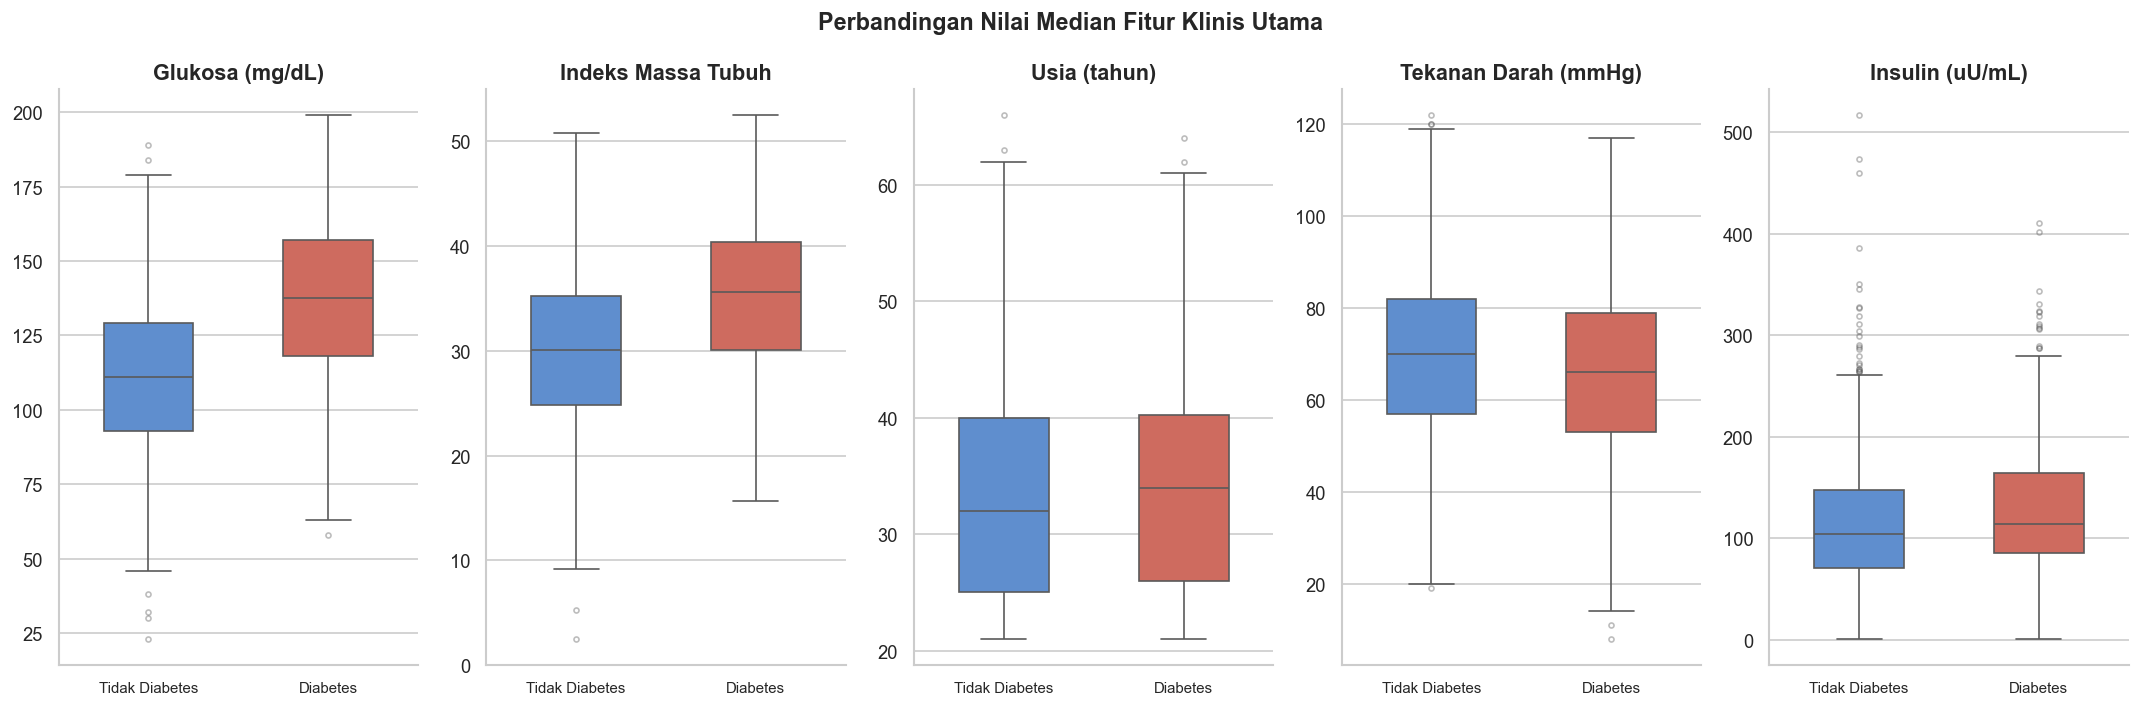

In [6]:
fitur = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']
label_fitur = {
    'Glucose'       : 'Glukosa (mg/dL)',
    'BMI'           : 'Indeks Massa Tubuh',
    'Age'           : 'Usia (tahun)',
    'BloodPressure' : 'Tekanan Darah (mmHg)',
    'Insulin'       : 'Insulin (uU/mL)',
}

fig, axes = plt.subplots(1, 5, figsize=(18, 6))
palet = {'Tidak Diabetes': '#4C8BE0', 'Diabetes': '#E05C4C'}

for i, col in enumerate(fitur):
    sns.boxplot(
        data=df_clean, x='Diagnosis', y=col,
        palette=palet, ax=axes[i], width=0.5,
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    axes[i].set_title(label_fitur[col])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', labelsize=9)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Perbandingan Nilai Median Fitur Klinis Utama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Grafik 4 - Tingkat Diabetes Berdasarkan Kategori BMI dan Kelompok Usia

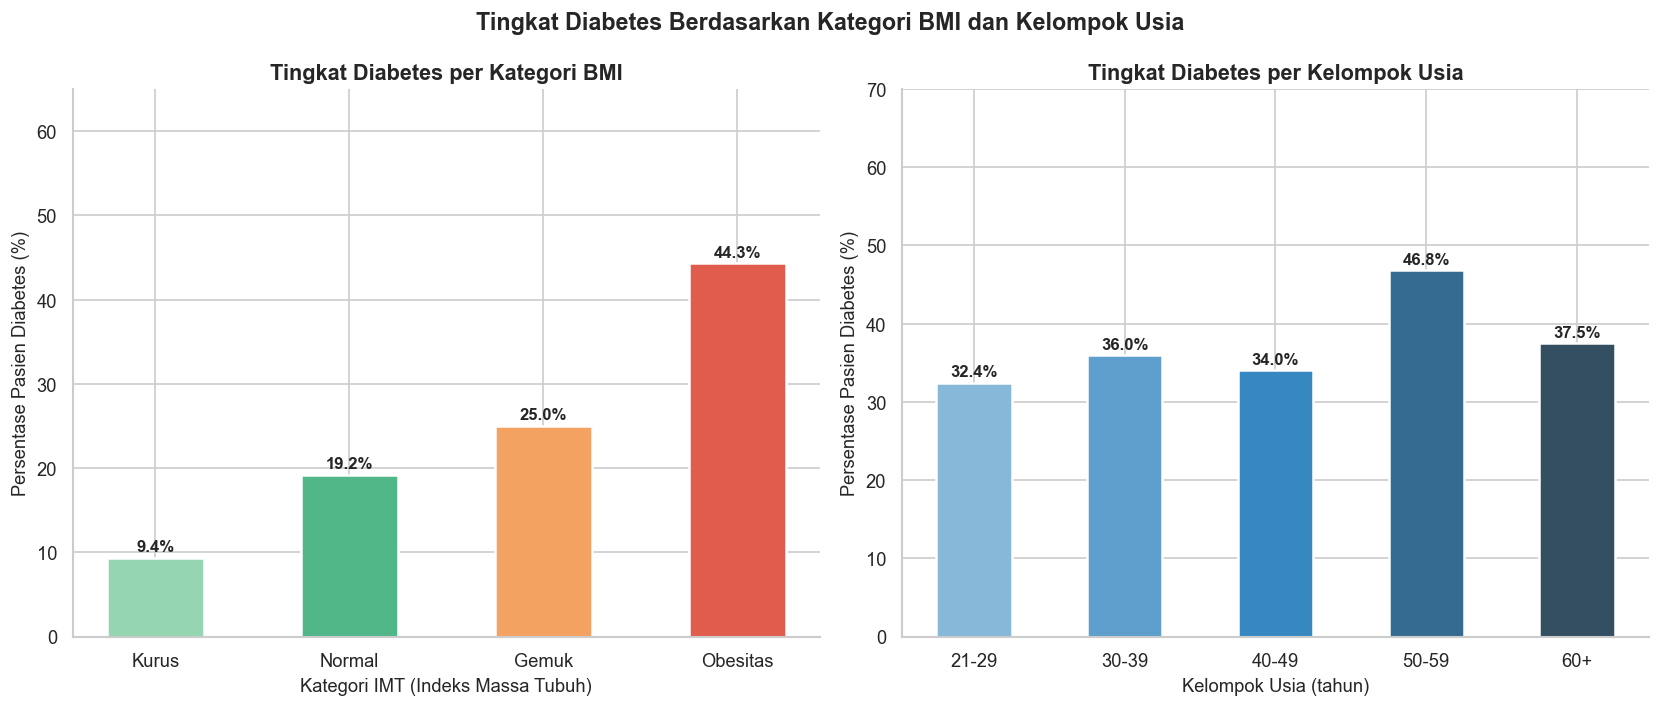

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# bmi
urutan_bmi  = ['Kurus', 'Normal', 'Gemuk', 'Obesitas']
warna_bmi   = ['#95D5B2', '#52B788', '#F4A261', '#E05C4C']
rate_bmi    = df_clean.groupby('Kategori_BMI')['Outcome'].mean().reindex(urutan_bmi) * 100

bar1 = axes[0].bar(rate_bmi.index, rate_bmi.values, color=warna_bmi,
                   edgecolor='white', linewidth=1.5, width=0.5)
for b, v in zip(bar1, rate_bmi.values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.8,
                 f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Tingkat Diabetes per Kategori BMI')
axes[0].set_xlabel('Kategori IMT (Indeks Massa Tubuh)')
axes[0].set_ylabel('Persentase Pasien Diabetes (%)')
axes[0].set_ylim(0, 65)
axes[0].spines[['top','right']].set_visible(False)

# usia
urutan_usia = ['21-29', '30-39', '40-49', '50-59', '60+']
rate_usia   = df_clean.groupby('Kelompok_Usia')['Outcome'].mean().reindex(urutan_usia) * 100
warna_usia  = sns.color_palette('Blues_d', len(urutan_usia))

bar2 = axes[1].bar(rate_usia.index, rate_usia.values, color=warna_usia,
                   edgecolor='white', linewidth=1.5, width=0.5)
for b, v in zip(bar2, rate_usia.values):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.8,
                 f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Tingkat Diabetes per Kelompok Usia')
axes[1].set_xlabel('Kelompok Usia (tahun)')
axes[1].set_ylabel('Persentase Pasien Diabetes (%)')
axes[1].set_ylim(0, 70)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Tingkat Diabetes Berdasarkan Kategori BMI dan Kelompok Usia',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Grafik 5 - Korelasi Antar Variabel Klinis

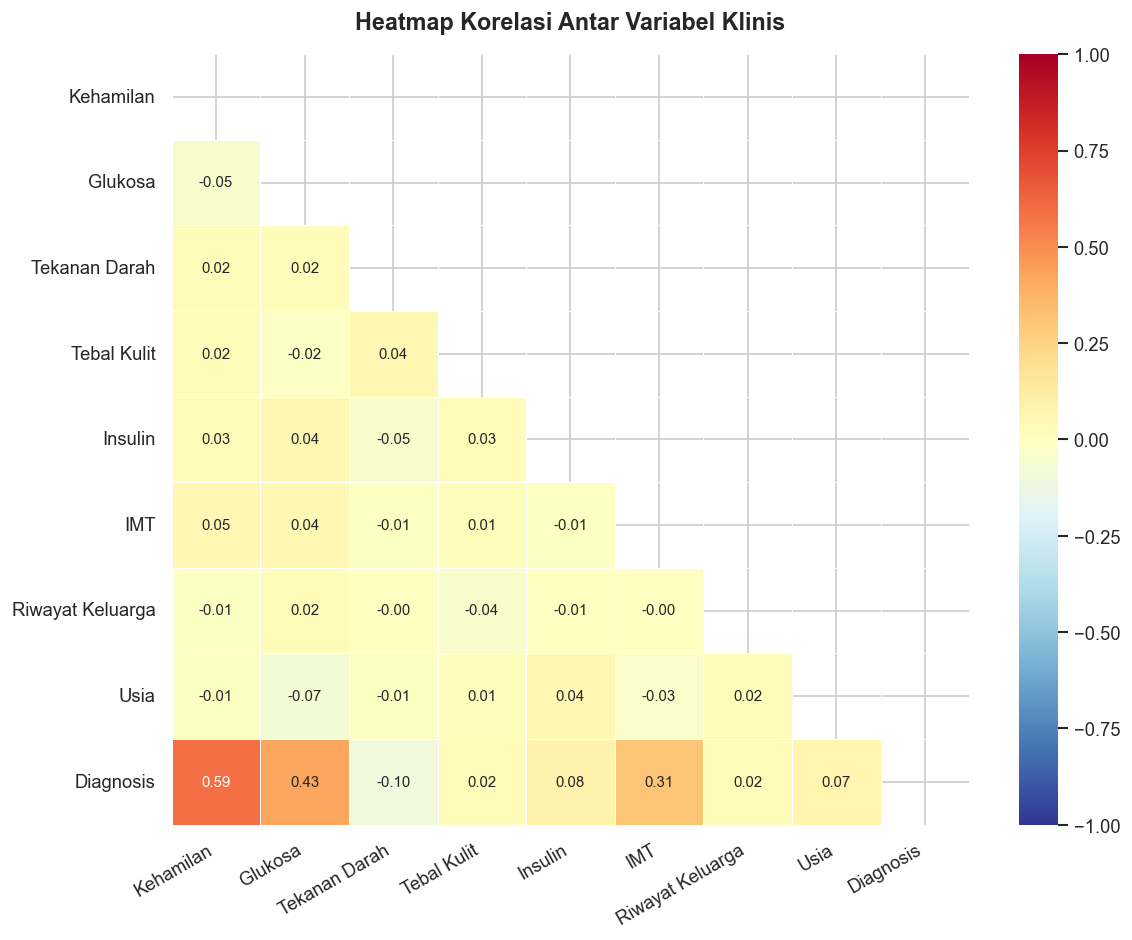

In [8]:
kolom_numerik = ['Kehamilan', 'Glukosa', 'Tekanan Darah', 'Tebal Kulit',
                 'Insulin', 'IMT', 'Riwayat Keluarga', 'Usia', 'Diagnosis']

df_korelasi = df_clean[['Pregnancies','Glucose','BloodPressure','SkinThickness',
                         'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']].copy()
df_korelasi.columns = kolom_numerik

corr = df_korelasi.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
    mask=mask, center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
plt.title('Heatmap Korelasi Antar Variabel Klinis', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
